# Select Best Disentanglement Methods

This notebook systematically selects the top-2 disentanglement methods from all nonlinear-noise experiment results on `halfcheetah-medium-v2`.

## Analysis pipeline
- **Cell 1**: Imports and project root setup
- **Cell 2**: Runtime parameters
- **Cell 3**: Load and validate data
- **Step 1**: Global mean ranking — average normalized score across all 16 (dim, scale) configs
- **Step 2**: Hard-condition robustness — performance on the 4 hardest configs (large dim + large scale)
- **Step 3**: Performance degradation curve — score drop as noise scale increases
- **Step 4**: Win rate vs. plain baseline — fraction of configs where method beats the baseline
- **Step 5**: Score heatmap — full (dim × scale) breakdown per method
- **Step 6**: Composite ranking and final verdict

In [1]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RAW_METRICS_DIR, TABLES_DIR

sns.set_theme(style="whitegrid", font_scale=1.15)
print(f"[INFO] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[INFO] RAW_METRICS_DIR = {RAW_METRICS_DIR}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'


[INFO] PROJECT_ROOT = /home/wyuhan/projects/robust-offline-rl-disentanglement
[INFO] RAW_METRICS_DIR = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics


No module named 'carla'
pybullet build time: Jan 29 2025 23:19:57
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/pybullet_envs/env_bases.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/home/wyuhan/miniconda3/envs/rl_env/lib/python3.8/site-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


In [2]:
# ── Runtime parameters ──────────────────────────────────────────────────────
TARGET_ENV   = "halfcheetah-medium-v2"
TARGET_TYPE  = "nonlinear"
TARGET_DIMS  = [4, 8, 13, 17]
TARGET_SCALES = [0.5, 1.0, 1.5, 2.0]
TARGET_SEEDS = [2]

# Disentanglement methods only (no baselines in ranking)
DISENTANGLE_METHODS = [
    "disentangled_cov",
    "disentangled_hsic",
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_infonce",
    "disentangled_l1",
]
BASELINE_METHODS = ["plain", "raw_noisy", "true_only"]
ALL_METHODS = DISENTANGLE_METHODS + BASELINE_METHODS

# Hard-condition threshold: dim >= HARD_DIM_THRESH AND scale >= HARD_SCALE_THRESH
HARD_DIM_THRESH   = 13
HARD_SCALE_THRESH = 1.5

SAVE_FIGURES = True
SAVE_TABLES  = True

FIGURE_OUT_DIR = FIGURES_DIR / "method_selection" / TARGET_ENV
TABLE_OUT_DIR  = TABLES_DIR  / "method_selection" / TARGET_ENV
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Display labels and color palette
METHOD_LABELS = {
    "true_only":            "No Noise (Oracle)",
    "plain":                "Plain Encoder",
    "raw_noisy":            "Raw Noisy",
    "disentangled_cov":     "Covariance",
    "disentangled_hsic":    "HSIC",
    "disentangled_barlow":  "Barlow",
    "disentangled_dcor":    "dCor",
    "disentangled_infonce": "InfoNCE",
    "disentangled_l1":      "L1",
}

PALETTE = {
    "No Noise (Oracle)": "#2c3e50",
    "Plain Encoder":     "#3498db",
    "Raw Noisy":         "#bdc3c7",
    "Covariance":        "#e74c3c",
    "HSIC":              "#d35400",
    "Barlow":            "#f39c12",
    "dCor":              "#8e44ad",
    "InfoNCE":           "#e84393",
    "L1":                "#00cec9",
}

print("[INFO] Parameters set.")

[INFO] Parameters set.


In [3]:
# ── Load experiment results ──────────────────────────────────────────────────
def load_records(raw_metrics_dir, all_methods, target_env,
                 target_dims, target_scales, target_type, target_seeds):
    """Walk raw_metrics_dir and collect all matching metrics.json entries."""
    records = []
    oracle_scores = []

    for json_path in raw_metrics_dir.rglob("*.json"):
        try:
            data = json.loads(json_path.read_text(encoding="utf-8"))
        except Exception:
            continue

        score = data.get("normalized_score")
        if score is None:
            continue

        path_str = str(json_path).replace("\\", "/")
        method = data.get("method") or data.get("group") or ""
        if not method:
            for m in all_methods:
                if f"/{m}/" in path_str:
                    method = m
                    break
        if method not in all_methods:
            continue

        env = data.get("env") or data.get("env_name") or ""
        if not env:
            for part in json_path.parts:
                if part == target_env:
                    env = part
                    break
        if env != target_env:
            continue

        seed = data.get("seed")
        if seed is None:
            m = re.search(r"seed_?(\d+)", path_str, re.IGNORECASE)
            seed = int(m.group(1)) if m else None
        else:
            seed = int(seed)

        if method == "true_only":
            oracle_scores.append(float(score))
            continue

        noise_dim   = data.get("noise_dim")
        noise_scale = data.get("noise_scale")
        noise_type  = data.get("noise_type")
        if noise_dim is None or noise_scale is None or noise_type is None:
            continue

        if noise_type  != target_type:          continue
        if int(noise_dim)    not in target_dims:   continue
        if float(noise_scale) not in target_scales: continue
        if seed is None or int(seed) not in target_seeds: continue

        records.append({
            "Method":  method,
            "Label":   METHOD_LABELS.get(method, method),
            "Dim":     int(noise_dim),
            "Scale":   float(noise_scale),
            "Type":    noise_type,
            "Seed":    int(seed),
            "Score":   float(score),
        })

    df = pd.DataFrame(records)
    oracle_mean = float(np.mean(oracle_scores)) if oracle_scores else None
    return df, oracle_mean


df, oracle_mean = load_records(
    RAW_METRICS_DIR, ALL_METHODS, TARGET_ENV,
    TARGET_DIMS, TARGET_SCALES, TARGET_TYPE, TARGET_SEEDS,
)

print(f"[INFO] Loaded {len(df)} records.")
print(f"[INFO] Methods found : {sorted(df['Method'].unique())}")
print(f"[INFO] Oracle (true_only) mean score = {oracle_mean:.3f}" if oracle_mean else "[WARN] No oracle records found.")
df.head(10)

[INFO] Loaded 128 records.
[INFO] Methods found : ['disentangled_barlow', 'disentangled_cov', 'disentangled_dcor', 'disentangled_hsic', 'disentangled_infonce', 'disentangled_l1', 'plain', 'raw_noisy']
[INFO] Oracle (true_only) mean score = 40.724


,Method,Label,Dim,Scale,Type,Seed,Score
0,disentangled_dcor,dCor,8,1.5,nonlinear,2,36.610604
1,disentangled_dcor,dCor,13,1.0,nonlinear,2,36.083307
2,disentangled_dcor,dCor,8,1.0,nonlinear,2,39.778586
3,disentangled_dcor,dCor,4,1.5,nonlinear,2,36.311526
4,disentangled_dcor,dCor,17,0.5,nonlinear,2,37.489689
5,disentangled_dcor,dCor,8,2.0,nonlinear,2,28.421804
6,disentangled_dcor,dCor,17,1.0,nonlinear,2,36.718584
7,disentangled_dcor,dCor,13,1.5,nonlinear,2,27.814007
8,disentangled_dcor,dCor,13,0.5,nonlinear,2,37.684348
9,disentangled_dcor,dCor,4,2.0,nonlinear,2,35.961040


## Step 1 — Global mean ranking

Average normalized score across **all 16 (dim, scale) configurations**.
This measures overall expected performance regardless of the specific noise setting.

Global mean normalized score (all 16 configs):
            Label  GlobalMean
No Noise (Oracle)   40.724106
             HSIC   35.525264
           Barlow   34.725603
             dCor   33.976688
       Covariance   33.859292
          InfoNCE   33.615580
    Plain Encoder   33.283298
               L1   32.792652
        Raw Noisy   30.286996
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step1_global_mean.png


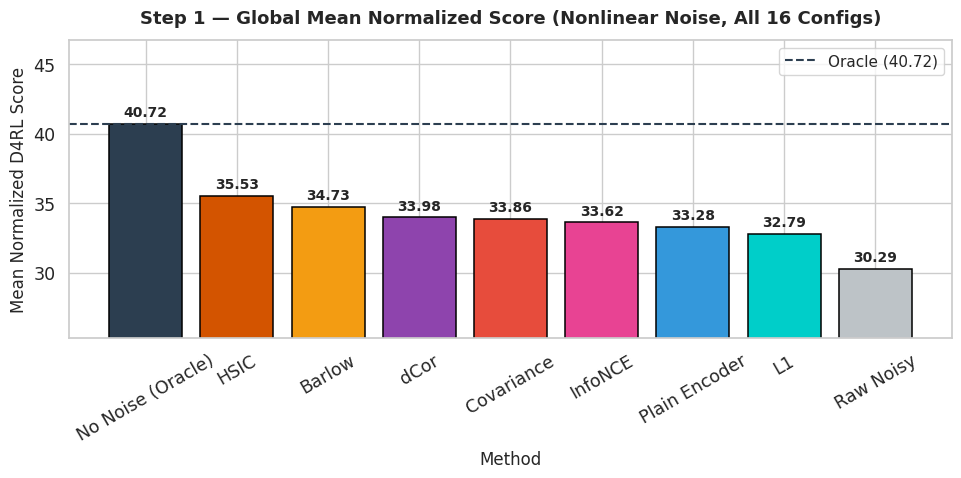

In [4]:
# ── Global mean per method ───────────────────────────────────────────────────
global_mean = (
    df.groupby("Method")["Score"]
    .mean()
    .rename("GlobalMean")
    .reset_index()
)
global_mean["Label"] = global_mean["Method"].map(METHOD_LABELS)
global_mean = global_mean.sort_values("GlobalMean", ascending=False).reset_index(drop=True)

if oracle_mean is not None:
    oracle_row = pd.DataFrame([{
        "Method": "true_only", "Label": "No Noise (Oracle)", "GlobalMean": oracle_mean
    }])
    global_mean = pd.concat([oracle_row, global_mean], ignore_index=True)

print("Global mean normalized score (all 16 configs):")
print(global_mean[["Label", "GlobalMean"]].to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in global_mean["Label"]]
bars = ax.bar(global_mean["Label"], global_mean["GlobalMean"], color=colors,
              edgecolor="black", linewidth=1.1)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

if oracle_mean is not None:
    ax.axhline(oracle_mean, color="#2c3e50", linestyle="--", linewidth=1.5,
               label=f"Oracle ({oracle_mean:.2f})")
    ax.legend(fontsize=11)

ax.set_title("Step 1 — Global Mean Normalized Score (Nonlinear Noise, All 16 Configs)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=12)
ax.set_xlabel("Method", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ymin = max(0, global_mean["GlobalMean"].min() - 5)
ax.set_ylim(ymin, global_mean["GlobalMean"].max() + 6)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step1_global_mean.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 2 — Hard-condition robustness

Average score on the **4 hardest configurations** only (`dim ≥ 13` AND `scale ≥ 1.5`).  
A method that leads here is genuinely robust to severe nonlinear corruption.

Hard configs (dim >= 13, scale >= 1.5): [(13, 1.5), (13, 2.0), (17, 1.5), (17, 2.0)]

Hard-condition mean (4 hardest configs):
        Label  HardMean
         HSIC 28.622362
       Barlow 28.011842
         dCor 25.972345
Plain Encoder 25.183293
      InfoNCE 24.750035
   Covariance 24.702679
           L1 23.916129
    Raw Noisy 20.655527
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step2_hard_condition.png


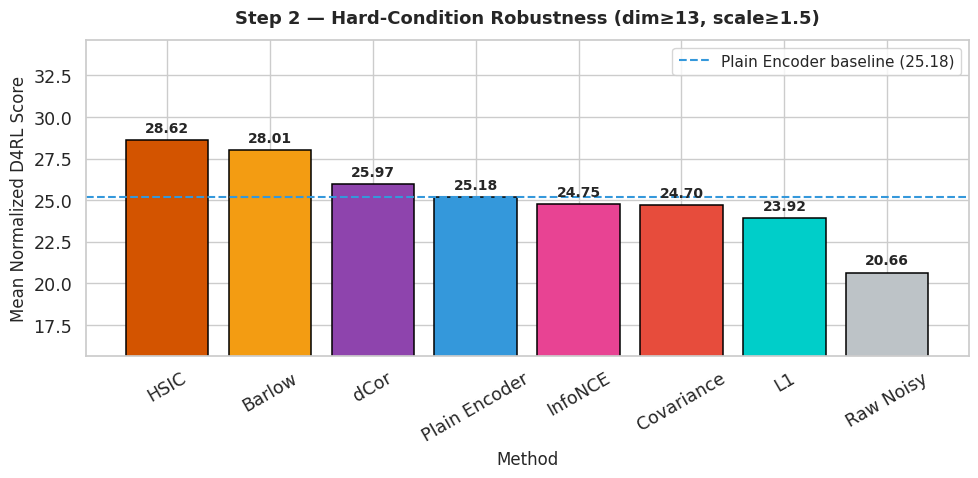

In [5]:
# ── Hard-condition mean ───────────────────────────────────────────────────────
df_hard = df[(df["Dim"] >= HARD_DIM_THRESH) & (df["Scale"] >= HARD_SCALE_THRESH)].copy()
hard_configs = [(d, s) for d in TARGET_DIMS if d >= HARD_DIM_THRESH
                        for s in TARGET_SCALES if s >= HARD_SCALE_THRESH]
print(f"Hard configs (dim >= {HARD_DIM_THRESH}, scale >= {HARD_SCALE_THRESH}): {hard_configs}")

hard_mean = (
    df_hard.groupby("Method")["Score"]
    .mean()
    .rename("HardMean")
    .reset_index()
)
hard_mean["Label"] = hard_mean["Method"].map(METHOD_LABELS)
hard_mean = hard_mean.sort_values("HardMean", ascending=False).reset_index(drop=True)

print("\nHard-condition mean (4 hardest configs):")
print(hard_mean[["Label", "HardMean"]].to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in hard_mean["Label"]]
bars = ax.bar(hard_mean["Label"], hard_mean["HardMean"], color=colors,
              edgecolor="black", linewidth=1.1)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plain_hard = hard_mean.loc[hard_mean["Method"] == "plain", "HardMean"]
if not plain_hard.empty:
    ax.axhline(float(plain_hard.iloc[0]), color="#3498db", linestyle="--", linewidth=1.5,
               label=f"Plain Encoder baseline ({float(plain_hard.iloc[0]):.2f})")
    ax.legend(fontsize=11)

ax.set_title(f"Step 2 — Hard-Condition Robustness (dim≥{HARD_DIM_THRESH}, scale≥{HARD_SCALE_THRESH})",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=12)
ax.set_xlabel("Method", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ymin = max(0, hard_mean["HardMean"].min() - 5)
ax.set_ylim(ymin, hard_mean["HardMean"].max() + 6)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step2_hard_condition.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 3 — Performance degradation curve

For each method, plot **score vs. noise scale** (averaged over all dims).  
A flatter curve indicates the method degrades more gracefully as noise intensifies.

Degradation from scale=0.5 to scale=2.0 (smaller drop = more robust):
        Label      Drop   DropPct
         HSIC  9.577997 24.397277
       Barlow  9.371934 24.812032
      InfoNCE  9.841807 26.270364
         dCor 10.646372 28.038461
   Covariance 11.495209 29.954049
Plain Encoder 14.087433 36.990830
           L1 14.400148 37.618575
    Raw Noisy 15.947960 42.390989
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step3_degradation_curve.png


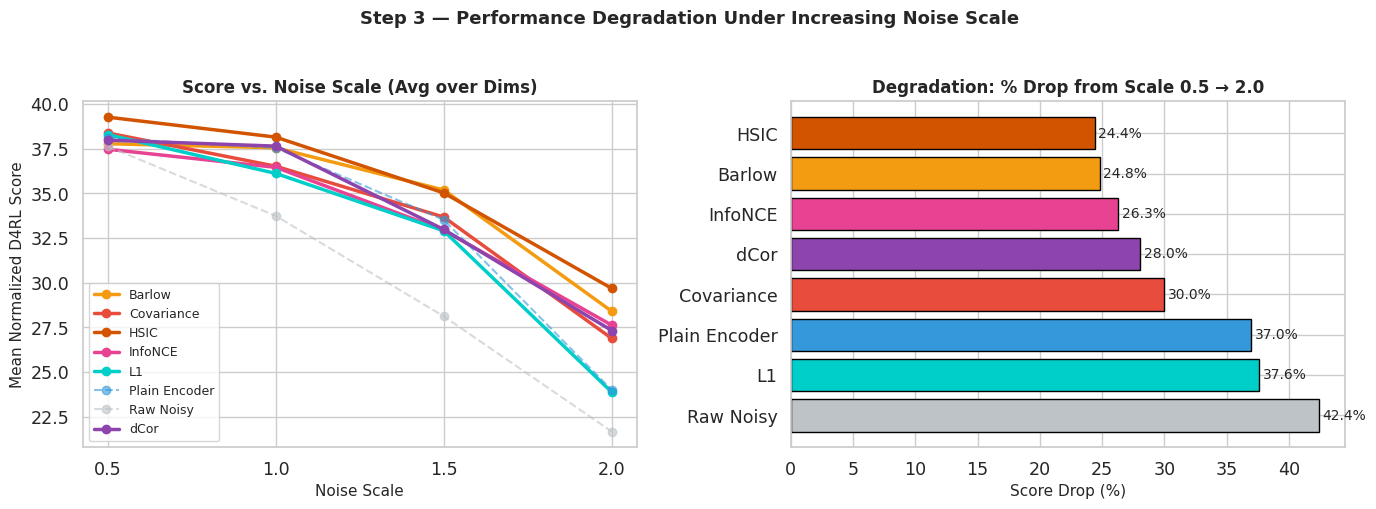

In [6]:
# ── Degradation curve ─────────────────────────────────────────────────────────
deg_df = (
    df.groupby(["Method", "Label", "Scale"])["Score"]
    .mean()
    .reset_index()
    .rename(columns={"Score": "MeanScore"})
)

# Compute drop: score at scale=2.0 minus score at scale=0.5 (negative = degradation)
score_05 = deg_df[deg_df["Scale"] == 0.5].set_index("Method")["MeanScore"]
score_20 = deg_df[deg_df["Scale"] == 2.0].set_index("Method")["MeanScore"]
drop_df = (score_05 - score_20).rename("Drop").reset_index()
drop_df["Label"] = drop_df["Method"].map(METHOD_LABELS)
drop_df["DropPct"] = drop_df["Drop"] / score_05.reindex(drop_df["Method"]).values * 100
drop_df = drop_df.sort_values("DropPct").reset_index(drop=True)  # lower % drop = better

print("Degradation from scale=0.5 to scale=2.0 (smaller drop = more robust):")
print(drop_df[["Label", "Drop", "DropPct"]].to_string(index=False))

# ── Line plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score vs scale curves
ax = axes[0]
disentangle_labels = [METHOD_LABELS[m] for m in DISENTANGLE_METHODS]
baseline_labels    = [METHOD_LABELS[m] for m in ["plain", "raw_noisy"]]

for _, grp in deg_df.groupby("Label"):
    lbl = grp["Label"].iloc[0]
    color = PALETTE.get(lbl, "#aaaaaa")
    lw = 2.5 if lbl in disentangle_labels else 1.5
    ls = "-" if lbl in disentangle_labels else "--"
    alpha = 1.0 if lbl in disentangle_labels else 0.6
    grp_sorted = grp.sort_values("Scale")
    ax.plot(grp_sorted["Scale"], grp_sorted["MeanScore"],
            marker="o", label=lbl, color=color,
            linewidth=lw, linestyle=ls, alpha=alpha)

ax.set_title("Score vs. Noise Scale (Avg over Dims)", fontsize=12, fontweight="bold")
ax.set_xlabel("Noise Scale", fontsize=11)
ax.set_ylabel("Mean Normalized D4RL Score", fontsize=11)
ax.xaxis.set_major_locator(mticker.FixedLocator(TARGET_SCALES))
ax.legend(fontsize=9, loc="lower left")

# Right: drop percentage bar chart
ax2 = axes[1]
colors2 = [PALETTE.get(lbl, "#aaaaaa") for lbl in drop_df["Label"]]
bars2 = ax2.barh(drop_df["Label"], drop_df["DropPct"], color=colors2,
                 edgecolor="black", linewidth=1.0)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{w:.1f}%", va="center", fontsize=10)

ax2.set_title("Degradation: % Drop from Scale 0.5 → 2.0", fontsize=12, fontweight="bold")
ax2.set_xlabel("Score Drop (%)", fontsize=11)
ax2.set_ylabel("")
ax2.invert_yaxis()  # best (lowest drop) on top

plt.suptitle("Step 3 — Performance Degradation Under Increasing Noise Scale",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step3_degradation_curve.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 4 — Win rate vs. plain baseline

For each of the 16 (dim, scale) configurations, check whether the method's score exceeds `plain`.  
**Win rate = fraction of configs where method strictly beats plain encoder.**  
This measures consistency: a method that wins 14/16 is more reliable than one that wins 4/16.

Win rate vs. plain encoder baseline:
     Label  Wins  Total  WinRate  AvgMargin
      HSIC    12     16   0.7500   2.241966
    Barlow    11     16   0.6875   1.442305
Covariance     9     16   0.5625   0.575994
      dCor     8     16   0.5000   0.693390
   InfoNCE     7     16   0.4375   0.332282
        L1     7     16   0.4375  -0.490646
[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step4_win_rate.png


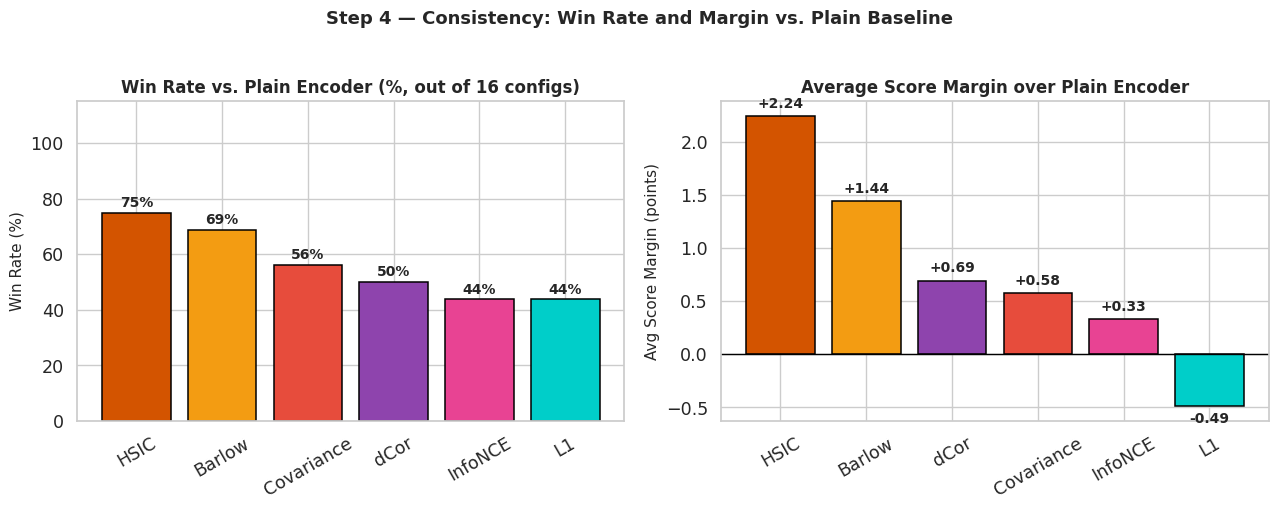

In [7]:
# ── Win rate ──────────────────────────────────────────────────────────────────
plain_scores = (
    df[df["Method"] == "plain"]
    .set_index(["Dim", "Scale"])["Score"]
    .rename("PlainScore")
)

win_records = []
for method in DISENTANGLE_METHODS:
    m_df = df[df["Method"] == method].set_index(["Dim", "Scale"])["Score"]
    joined = m_df.to_frame("Score").join(plain_scores, how="inner")
    n_total = len(joined)
    n_win   = int((joined["Score"] > joined["PlainScore"]).sum())
    margin  = float((joined["Score"] - joined["PlainScore"]).mean())
    win_records.append({
        "Method":   method,
        "Label":    METHOD_LABELS[method],
        "WinRate":  n_win / n_total if n_total > 0 else 0.0,
        "AvgMargin": margin,
        "Wins":     n_win,
        "Total":    n_total,
    })

win_df = pd.DataFrame(win_records).sort_values("WinRate", ascending=False).reset_index(drop=True)
print("Win rate vs. plain encoder baseline:")
print(win_df[["Label", "Wins", "Total", "WinRate", "AvgMargin"]].to_string(index=False))

# ── Dual bar chart: win rate + avg margin ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Win rate
ax = axes[0]
colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in win_df["Label"]]
bars = ax.bar(win_df["Label"], win_df["WinRate"] * 100, color=colors,
              edgecolor="black", linewidth=1.1)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.0f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Win Rate vs. Plain Encoder (%, out of 16 configs)", fontsize=12, fontweight="bold")
ax.set_ylabel("Win Rate (%)", fontsize=11)
ax.set_ylim(0, 115)
ax.tick_params(axis="x", rotation=30)

# Avg score margin
ax2 = axes[1]
margin_df = win_df.sort_values("AvgMargin", ascending=False)
colors2 = [PALETTE.get(lbl, "#aaaaaa") for lbl in margin_df["Label"]]
bars2 = ax2.bar(margin_df["Label"], margin_df["AvgMargin"], color=colors2,
                edgecolor="black", linewidth=1.1)
for bar in bars2:
    h = bar.get_height()
    va = "bottom" if h >= 0 else "top"
    offset = 0.05 if h >= 0 else -0.05
    ax2.text(bar.get_x() + bar.get_width() / 2, h + offset, f"{h:+.2f}",
             ha="center", va=va, fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=1.0, linestyle="-")
ax2.set_title("Average Score Margin over Plain Encoder", fontsize=12, fontweight="bold")
ax2.set_ylabel("Avg Score Margin (points)", fontsize=11)
ax2.tick_params(axis="x", rotation=30)

plt.suptitle("Step 4 — Consistency: Win Rate and Margin vs. Plain Baseline",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step4_win_rate.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 5 — Score heatmap

Full breakdown of each method's normalized score across all (dim, scale) pairs.  
Allows visual inspection of where each method is strong or weak.

[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step5_score_heatmap.png


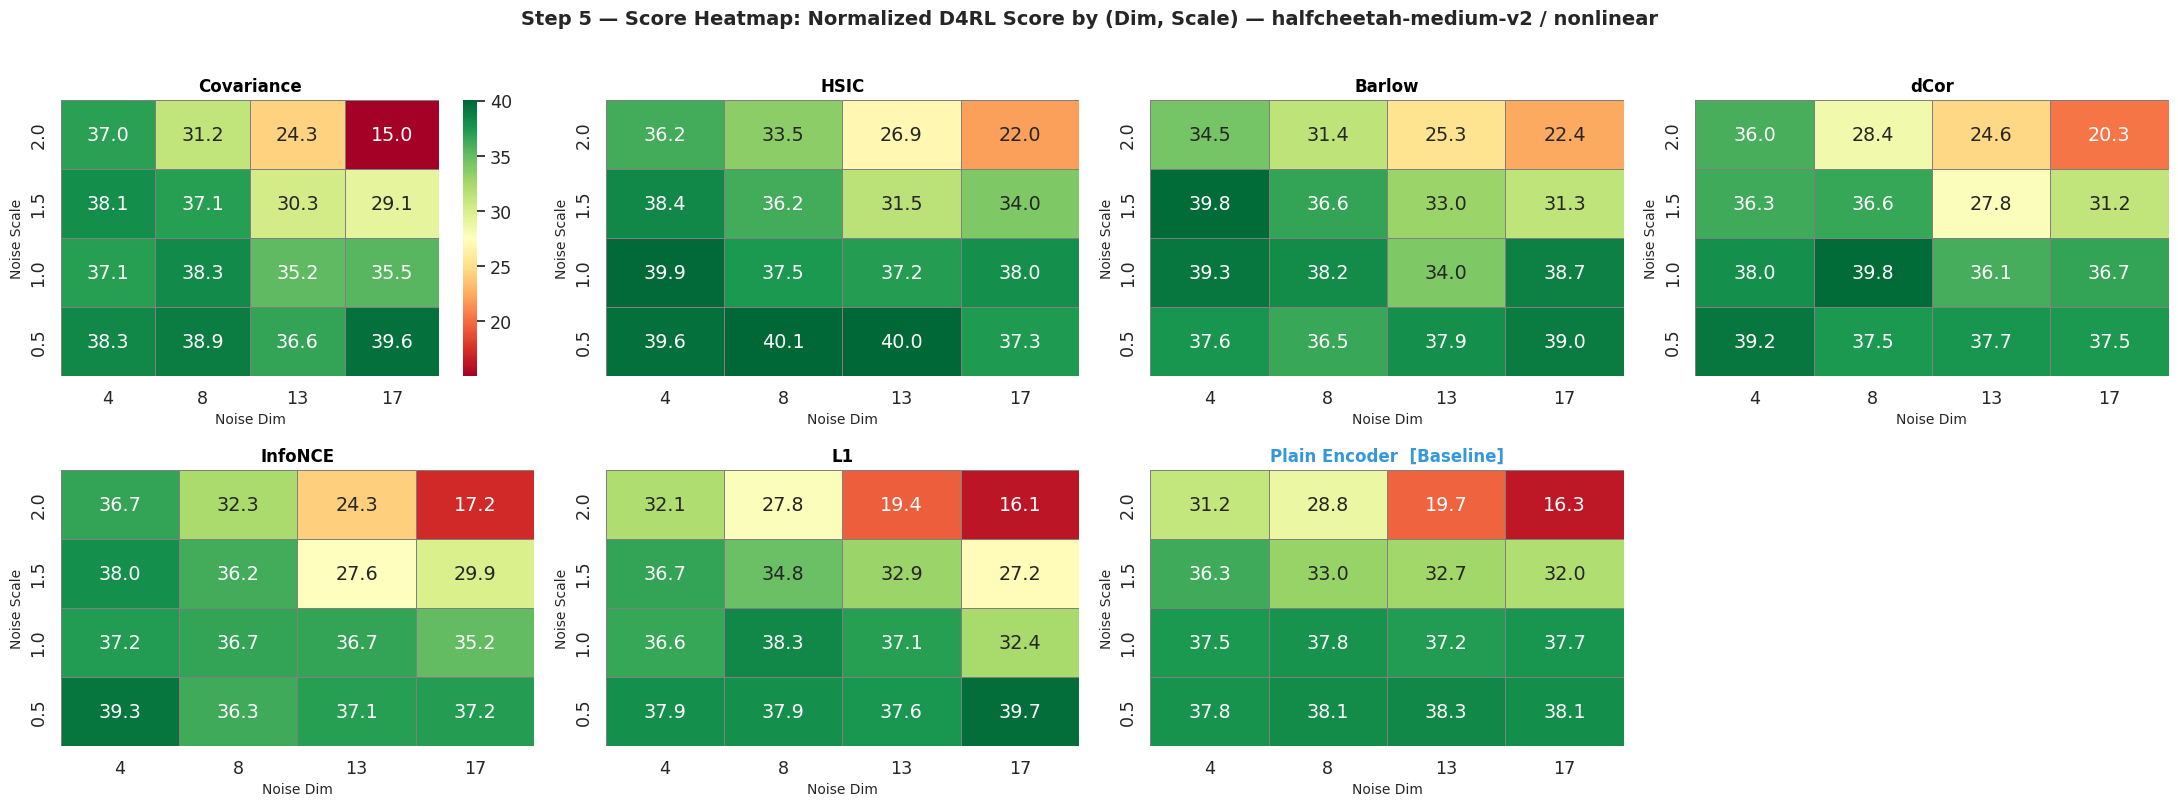

In [8]:
# ── Heatmaps: disentangle methods + plain baseline ────────────────────────────
methods_to_plot = DISENTANGLE_METHODS + ["plain"]
n_methods = len(methods_to_plot)
ncols = 4
nrows = (n_methods + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

vmin = df["Score"].min()
vmax = df["Score"].max()

for i, method in enumerate(methods_to_plot):
    m_df = df[df["Method"] == method]
    pivot = m_df.pivot_table(index="Scale", columns="Dim", values="Score", aggfunc="mean")
    pivot = pivot.sort_index(ascending=False)  # high scale at top

    label = METHOD_LABELS.get(method, method)
    ax = axes[i]
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".1f", cmap="RdYlGn",
        vmin=vmin, vmax=vmax, linewidths=0.5, linecolor="grey",
        cbar=(i == 0),
    )
    is_plain = method == "plain"
    title_suffix = "  [Baseline]" if is_plain else ""
    ax.set_title(f"{label}{title_suffix}",
                 fontsize=12, fontweight="bold",
                 color="#3498db" if is_plain else "black")
    ax.set_xlabel("Noise Dim", fontsize=10)
    ax.set_ylabel("Noise Scale", fontsize=10)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Step 5 — Score Heatmap: Normalized D4RL Score by (Dim, Scale) — {TARGET_ENV} / {TARGET_TYPE}",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step5_score_heatmap.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

## Step 6 — Composite ranking and final verdict

Aggregate the four metrics into a single composite score using **normalized ranks**:

| Metric | Weight | Direction |
|--------|--------|-----------|
| Global mean | 0.30 | higher is better |
| Hard-condition mean | 0.35 | higher is better |
| Degradation drop % | 0.20 | lower is better |
| Win rate vs. plain | 0.15 | higher is better |

Hard-condition mean is weighted highest because this setting best distinguishes methods that
truly disentangle from those that only improve marginally.

In [9]:
# ── Build composite ranking ──────────────────────────────────────────────────
WEIGHTS = {
    "GlobalMean":  0.30,
    "HardMean":    0.35,
    "DropPct":     0.20,   # lower is better → invert
    "WinRate":     0.15,
}

# Merge all metrics (disentanglement methods only)
comp = (
    global_mean[global_mean["Method"].isin(DISENTANGLE_METHODS)][["Method", "Label", "GlobalMean"]]
    .merge(hard_mean[["Method", "HardMean"]], on="Method", how="inner")
    .merge(drop_df[["Method", "DropPct"]], on="Method", how="inner")
    .merge(win_df[["Method", "WinRate"]], on="Method", how="inner")
)

# Min-max normalize each metric to [0, 1]; invert DropPct so higher=better
def minmax(series, invert=False):
    lo, hi = series.min(), series.max()
    norm = (series - lo) / (hi - lo) if hi > lo else pd.Series([0.5] * len(series), index=series.index)
    return 1 - norm if invert else norm

comp["n_GlobalMean"] = minmax(comp["GlobalMean"])
comp["n_HardMean"]   = minmax(comp["HardMean"])
comp["n_DropPct"]    = minmax(comp["DropPct"], invert=True)
comp["n_WinRate"]    = minmax(comp["WinRate"])

comp["Composite"] = (
    WEIGHTS["GlobalMean"] * comp["n_GlobalMean"]
    + WEIGHTS["HardMean"]   * comp["n_HardMean"]
    + WEIGHTS["DropPct"]    * comp["n_DropPct"]
    + WEIGHTS["WinRate"]    * comp["n_WinRate"]
)

comp = comp.sort_values("Composite", ascending=False).reset_index(drop=True)
comp["Rank"] = range(1, len(comp) + 1)

display_cols = ["Rank", "Label", "GlobalMean", "HardMean", "DropPct", "WinRate", "Composite"]
comp_display = comp[display_cols].copy()
comp_display.columns = ["Rank", "Method", "Global Mean", "Hard Mean",
                         "Drop % (↓)", "Win Rate", "Composite Score"]
print("Composite ranking (higher = better):")
print(comp_display.to_string(index=False))

if SAVE_TABLES:
    out = TABLE_OUT_DIR / "composite_ranking.csv"
    comp_display.to_csv(out, index=False)
    print(f"\n[INFO] Saved composite ranking table to: {out}")

Composite ranking (higher = better):
 Rank     Method  Global Mean  Hard Mean  Drop % (↓)  Win Rate  Composite Score
    1       HSIC    35.525264  28.622362   24.397277    0.7500         1.000000
    2     Barlow    34.725603  28.011842   24.812032    0.6875         0.830531
    3       dCor    33.976688  25.972345   28.038461    0.5000         0.457829
    4 Covariance    33.859292  24.702679   29.954049    0.5625         0.351539
    5    InfoNCE    33.615580  24.750035   26.270364    0.4375         0.324028
    6         L1    32.792652  23.916129   37.618575    0.4375         0.000000

[INFO] Saved composite ranking table to: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/tables/method_selection/halfcheetah-medium-v2/composite_ranking.csv


[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step6_composite_ranking.png


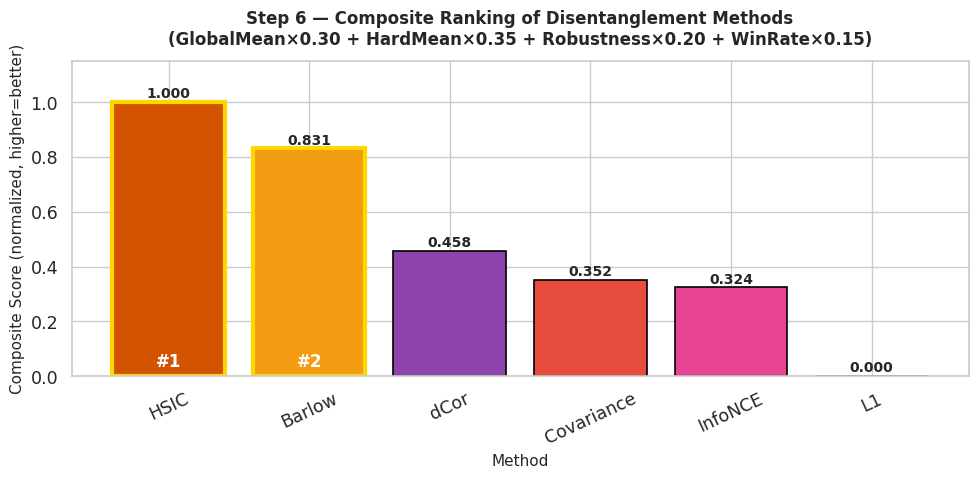

In [10]:
# ── Composite score bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE.get(lbl, "#aaaaaa") for lbl in comp["Label"]]
bars = ax.bar(comp["Label"], comp["Composite"], color=colors,
              edgecolor="black", linewidth=1.2)

for idx, (bar, row) in enumerate(zip(bars, comp.itertuples())):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    if row.Rank <= 2:
        bar.set_linewidth(3)
        bar.set_edgecolor("gold")
        ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
                f"#{row.Rank}", ha="center", va="bottom", fontsize=12,
                fontweight="bold", color="white")

ax.set_title(
    "Step 6 — Composite Ranking of Disentanglement Methods\n"
    "(GlobalMean×0.30 + HardMean×0.35 + Robustness×0.20 + WinRate×0.15)",
    fontsize=12, fontweight="bold", pad=12,
)
ax.set_ylabel("Composite Score (normalized, higher=better)", fontsize=11)
ax.set_xlabel("Method", fontsize=11)
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, 1.15)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step6_composite_ranking.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

[INFO] Saved: /home/wyuhan/projects/robust-offline-rl-disentanglement/results/figures/method_selection/halfcheetah-medium-v2/step6_radar_chart.png


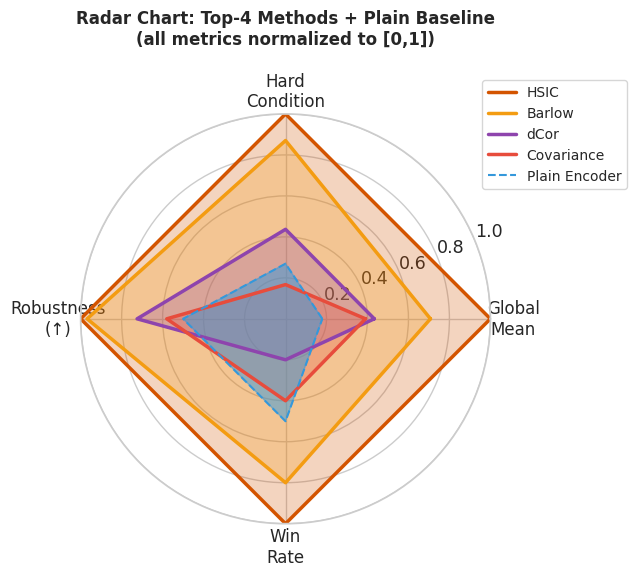

In [11]:
# ── Radar chart: top-4 methods vs plain ──────────────────────────────────────
top4 = comp.head(4)["Method"].tolist() + ["plain"]
radar_methods = [m for m in top4 if m in comp["Method"].tolist() or m == "plain"]

# Metrics for radar (all normalized to [0,1], higher=better)
radar_metrics = {
    "Global\nMean": lambda m: float(comp.loc[comp["Method"] == m, "n_GlobalMean"].iloc[0]) if m in comp["Method"].values else 0.5,
    "Hard\nCondition": lambda m: float(comp.loc[comp["Method"] == m, "n_HardMean"].iloc[0]) if m in comp["Method"].values else 0.5,
    "Robustness\n(↑)": lambda m: float(comp.loc[comp["Method"] == m, "n_DropPct"].iloc[0]) if m in comp["Method"].values else 0.5,
    "Win\nRate": lambda m: float(comp.loc[comp["Method"] == m, "n_WinRate"].iloc[0]) if m in comp["Method"].values else 0.5,
}

# Plain baseline normalized scores
plain_global = float(global_mean.loc[global_mean["Method"] == "plain", "GlobalMean"].iloc[0]) if "plain" in global_mean["Method"].values else None
plain_hard   = float(hard_mean.loc[hard_mean["Method"] == "plain", "HardMean"].iloc[0]) if "plain" in hard_mean["Method"].values else None

labels = list(radar_metrics.keys())
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for method in radar_methods:
    lbl = METHOD_LABELS.get(method, method)
    is_plain = method == "plain"

    if is_plain:
        # Compute plain's normalized values relative to comp range
        plain_g_norm = (plain_global - global_mean[global_mean["Method"].isin(DISENTANGLE_METHODS)]["GlobalMean"].min()) / \
                       (global_mean[global_mean["Method"].isin(DISENTANGLE_METHODS)]["GlobalMean"].max() -
                        global_mean[global_mean["Method"].isin(DISENTANGLE_METHODS)]["GlobalMean"].min() + 1e-9)
        plain_h_norm = (plain_hard - hard_mean[hard_mean["Method"].isin(DISENTANGLE_METHODS)]["HardMean"].min()) / \
                       (hard_mean[hard_mean["Method"].isin(DISENTANGLE_METHODS)]["HardMean"].max() -
                        hard_mean[hard_mean["Method"].isin(DISENTANGLE_METHODS)]["HardMean"].min() + 1e-9)
        values = [np.clip(plain_g_norm, 0, 1), np.clip(plain_h_norm, 0, 1), 0.5, 0.5]
    else:
        values = [fn(method) for fn in radar_metrics.values()]

    values += values[:1]
    color = PALETTE.get(lbl, "#aaaaaa")
    lw = 1.5 if is_plain else 2.5
    ls = "--" if is_plain else "-"
    alpha = 0.5 if is_plain else 0.25
    ax.plot(angles, values, linewidth=lw, linestyle=ls, label=lbl, color=color)
    ax.fill(angles, values, alpha=alpha, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Radar Chart: Top-4 Methods + Plain Baseline\n(all metrics normalized to [0,1])",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()

if SAVE_FIGURES:
    out = FIGURE_OUT_DIR / "step6_radar_chart.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved: {out}")
plt.show()

In [12]:
# ── Final verdict ─────────────────────────────────────────────────────────────
top2 = comp.head(2)
print("=" * 60)
print("FINAL VERDICT — Top-2 Disentanglement Methods")
print(f"Environment : {TARGET_ENV}")
print(f"Noise type  : {TARGET_TYPE}")
print("=" * 60)
for _, row in top2.iterrows():
    print(f"\n#{int(row['Rank'])}  {row['Label']}  (method key: {row['Method']})")
    print(f"    Global mean score  : {row['GlobalMean']:.3f}")
    print(f"    Hard-condition mean: {row['HardMean']:.3f}")
    print(f"    Score drop (0.5→2.0): {row['DropPct']:.1f}%")
    print(f"    Win rate vs. plain : {row['WinRate']:.2f}  ({int(row['WinRate']*16)}/16 configs)")
    print(f"    Composite score    : {row['Composite']:.4f}")

print("\n" + "=" * 60)
oracle_str = f"{oracle_mean:.3f}" if oracle_mean else "N/A"
print(f"Oracle (no noise) reference score: {oracle_str}")
plain_global_val = float(global_mean.loc[global_mean["Method"] == "plain", "GlobalMean"].iloc[0]) \
    if "plain" in global_mean["Method"].values else float("nan")
print(f"Plain encoder baseline mean score: {plain_global_val:.3f}")
print("=" * 60)

FINAL VERDICT — Top-2 Disentanglement Methods
Environment : halfcheetah-medium-v2
Noise type  : nonlinear

#1  HSIC  (method key: disentangled_hsic)
    Global mean score  : 35.525
    Hard-condition mean: 28.622
    Score drop (0.5→2.0): 24.4%
    Win rate vs. plain : 0.75  (12/16 configs)
    Composite score    : 1.0000

#2  Barlow  (method key: disentangled_barlow)
    Global mean score  : 34.726
    Hard-condition mean: 28.012
    Score drop (0.5→2.0): 24.8%
    Win rate vs. plain : 0.69  (11/16 configs)
    Composite score    : 0.8305

Oracle (no noise) reference score: 40.724
Plain encoder baseline mean score: 33.283
